## Speech Systems (EE6307)

#### Programming Assignment - 01 - Voiced / Unvoiced detection and $F_{0}$ estimation using auto correlation sequence

#### $\underline{\textbf{Objective}}$

Welcome to the first programming assignment (PA) in speech systems (EE6307) course. In this programming assignment, you need to code an algorithm to tag the frames of the given speech signal with voiced, unvoiced and silent labels. Also, write an algorithm to compute the fundamentatal frequency $(F_{0})$ of the voiced frames. In the upcoming programming assignments, more sophisticated voice activity detection and $F_{0}$ estimation methods will be assigned as a task. However, in this PA, we request you to use only the autocorrelation sequence to complete the job. Python modules to record the speech data are included in the notebook. You can either read the speech signals from the drive or record the speech signals using the provided modules for completing the PA.

#### $\underline{\textbf{Instructions}}$

Please follow these instructions

1. Late submissions are not allowed.

2. Plagiarism is strictly prohibited.

3. You're welcome to use AI tools to help write your code, but keep in mind that grading will focus on the depth of your own effort and understanding, which is usually easy to distinguish from AI-generated work.


#### $\underline{\textbf{Steps}}$

Follow these steps to complete the PA

1. Record and load the speech signal.
2. Manual sample-level annotation
    - Mark the voiced, unvoiced, and silent regions directly on the raw waveform of your recording, by ear and eye, at the sample level.
3. Frame the speech signal.
4. Voiced / Unvoiced activity detection
    - Compute the autocorrelation sequence for each frame.
    - Identify the location of the second peak in the autocorrelation sequence.
    - Compare the strength of the second peak with a threshold. If the strength exceeds the threshold, classify the frame as voiced; otherwise, classify it as unvoiced.
5. Unvoiced / Silent Classification
    - Compute the energy of frames that are not classified as voiced.
    - If the energy exceeds a certain threshold, classify the frame as unvoiced. Note that the threshold is a hyperparameter that should be optimized empirically.
    - If the energy is below the threshold, classify the frame as silent.
6. Evaluation against your manual ground truth
    - Collapse your sample-level manual labels onto the frame grid by taking the dominant class within each frame.
    - Compare against your algorithm's per-frame decisions using a confusion matrix and the overall frame-level accuracy.
7. Illustrations
    - Create a plot with two subplots.
    - In the first subplot, display the time-domain waveform of the speech signal and differentiate the voiced, unvoiced, and silent frames using distinct colors.
    - In the second subplot, display the fundamental frequency of the voiced frames.
    - You are requested to show the results with the following speech signal.
    
    [link to example speech signal](https://drive.google.com/file/d/15QwZBjwDEnxBFxS7gWzcCEEMX3yaqpJG/view?usp=drive_link)

8. Benchmark evaluation on the Keele pitch database [Link to the Keele database](https://drive.google.com/drive/folders/1r8IZ-WnEEF-dFhgEFBv0bfeSQ1O7CBaN?usp=drive_link)
    - Run the same system over the ten Keele speakers, whose reference $F_{0}$ comes from a laryngograph.
    - 8.1 Voicing detection: report the miss rate and the false alarm rate.
    - 8.2 $F_{0}$ estimation: report Gross Pitch Error and Fine Pitch Error.
9. Study of submodules in voice activity detection and $F_{0}$ estimation
    1. Examine how frame size impacts voice activity detection and fundamental frequency estimation.
        - Try using different frame sizes and observe how they affect the quality of the tags.
    2. Examine the effects of preprocessing the waveform, such as mean subtraction and max normalization, on the analysis.
    3. Plot and analyze the $F_{0}$ contour for the 'sa-pa-sa' vocals.

        [link to 'sa-pa-sa' vocals](https://drive.google.com/file/d/1RtLM87SyClOF_yfUFuV05LlwmXNAxAZN/view?usp=drive_link)

    4. Why the autocorrelation function rolls off with lag? what other methods can be employed to prevent it?

10. Provide a detailed report of your observations for each experiment.


#### 1) Speech recording

This part of the PA includes modules for recording the speech signal in an online mode.


In [1]:
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode
from io import BytesIO
!pip -q install pydub
from pydub import AudioSegment

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def record(sec=3):
  display(Javascript(RECORD))
  s = output.eval_js('record(%d)' % (sec*1000))
  b = b64decode(s.split(',')[1])
  audio = AudioSegment.from_file(BytesIO(b))
  return audio

######################## Module for recording the speech signal ########################
#1. The below code records the speech signal for 3 sec ( you can change the duration of the recording in the code ) and store it as 'recording.wav' <br/>
#2. If you have already recorded or uploaded the file named 'recording.wav', the code uses that file. Otherwise, it records and saves the file with the name 'recording.wav.'


from matplotlib import pyplot as plt
import numpy as np
import scipy.io.wavfile
import io
import os

#### Please comment below line, if you already uploaded the 'recording.wav' in '/content/'
!rm recording.wav

if os.path.isfile('recording.wav'):
    print("wavefile exists, later part of the code uses 'recording.wav' as input speech")
    (rate,sig) = scipy.io.wavfile.read("recording.wav")
    print(len(sig))
else:
    print("There is no file in the current directory, please record your voice")
    print("Recording started!")
    wav = record(3.0) #It will record three seconds of your speech
    wav = wav.set_frame_rate(16000)
    sig=wav.get_array_of_samples()
    samples=np.array(sig).T.astype(np.float32)
    fp_arr = np.array(samples).T.astype(np.float32)
    fp_arr /= np.iinfo(sig.typecode).max
    scipy.io.wavfile.write('recording.wav', 16000, fp_arr)
    plt.plot(fp_arr)
    plt.show()

ModuleNotFoundError: No module named 'google'

In [ ]:
######################## Reading speech signal ########################
import numpy as np
import scipy.io.wavfile
import soundfile as sf
from google.colab import drive

# Set exactly one of the below flags to True based on your convenience
read_from_googleDrive = False
read_from_colab = True  # Reads recorded wavefile in colab

if read_from_googleDrive:
    # Mount the drive
    drive.mount('/content/drive')
    # wavefile location in drive
    wavefile = '/content/drive/My Drive/example.wav'
    (rate, sig) = scipy.io.wavfile.read(wavefile)
if read_from_colab:
    # By default, the recorded file gets saved as 'recording.wav'
    (rate, sig) = scipy.io.wavfile.read('recording.wav')

print(sig.shape)


In [2]:
!pip -q install gdown
!gdown 1jRrMqrz4NR8x1F6-sbk2I5wSMcti7jD5 -O example.wav

import scipy.io.wavfile
import numpy as np
(rate, sig) = scipy.io.wavfile.read('example.wav')
sig = sig.astype(np.float32)
print(rate, sig.shape)

'C:\App\Python313\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.
Downloading...
From: https://drive.google.com/uc?id=1jRrMqrz4NR8x1F6-sbk2I5wSMcti7jD5
To: c:\Users\aanuu\Downloads\example.wav

  0%|          | 0.00/250k [00:00<?, ?B/s]
100%|██████████| 250k/250k [00:00<00:00, 1.14MB/s]
100%|██████████| 250k/250k [00:00<00:00, 1.14MB/s]


16000 (124826,)


#### 2) Manual sample-level annotation

Before you build any algorithm, mark up the ground truth for your own recording by hand — directly on the raw waveform. This is a perceptual judgment call that you should take by listening to your own voice.

1. Use `play_segment` below to listen to portions of `sig` (give start/end times in seconds).
2. Record your judgment as a list of contiguous `(start_time_sec, end_time_sec, label)` segments in `manual_segments`, where `label` is `'V'` (voiced), `'U'` (unvoiced), or `'S'` (silent). The segments must cover the full duration of `sig` with no gaps or overlaps.
3. Run `expand_segments_to_samples` to turn `manual_segments` into `manual_sample_labels`, a per-sample array the same length as `sig`.
4. Plot `sig` with `manual_sample_labels` overlaid (color-coded) as a sanity check, and adjust `manual_segments` if the coloring doesn't match what you hear/see.

You will reuse `manual_sample_labels` in Section 6 to evaluate your automatic voiced/unvoiced/silent classifier.


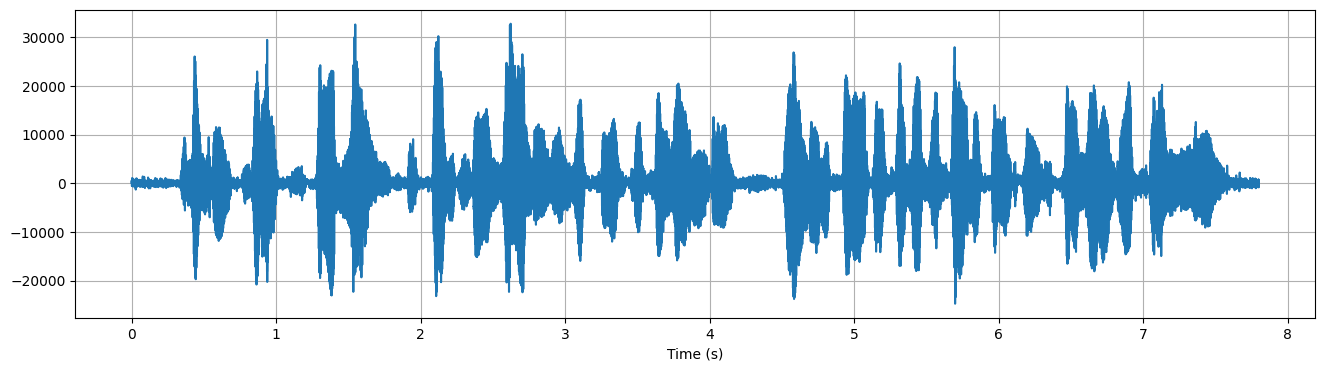

Duration: 7.801625 seconds


In [3]:
import matplotlib.pyplot as plt
time_axis = np.arange(len(sig)) / rate
plt.figure(figsize=(16,4))
plt.plot(time_axis, sig)
plt.xlabel('Time (s)')
plt.grid(True)
plt.show()
print("Duration:", len(sig)/rate, "seconds")

In [4]:
import IPython.display as ipd

def play_segment(sig, rate, start_sec, end_sec):
    # Plays back sig[start_sec:end_sec] so you can listen and judge voicing/silence by ear
    start = int(start_sec * rate)
    end = int(end_sec * rate)
    return ipd.Audio(sig[start:end], rate=rate)

# Example usage: listen to the first second of your recording
# play_segment(sig, rate, 0.0, 1.0)

#####################################
# List your manual judgments as contiguous (start_time_sec, end_time_sec, label) segments,
# where label is 'V' (voiced), 'U' (unvoiced), or 'S' (silent).
# The segments must cover [0, len(sig)/rate) with no gaps or overlaps.
manual_segments = [
    (0.00, 0.34, 'S'),

    (0.34, 0.386, 'U'),
    (0.386,0.479,'V'),
    (0.479,0.564,'U'),
    (0.564,0.69,'V'),

    (0.69, 0.76, 'S'),

    (0.76, 0.85, 'U'),
    (0.85, 1.00, 'V'),
    (1.00,1.087,'S'),
    (1.087,1.19, 'U'),
    (1.19,1.278,'S'),

    (1.274, 1.803, 'V'),
    (1.803,1.91,'U'),
    (1.91,1.97,'V'),
    (1.97,2.07,'S'),

    (2.07,2.23,'V'),

    (2.23,2.36,'U'),


    (2.36,3.125,'V'),

    (3.125,3.24,'U'),
    (3.24,3.37,'V'),
    (3.37,3.41,'U'),
    (3.41,3.456,'S'),
    (3.456,3.482,'U'),

    (3.482,3.535,'V'),

    (3.53,3.623,'U'),
    (3.623,4.17,'V'),

    (4.17, 4.512, 'S'),

    (4.512,4.83,'V'),

    (4.83,4.922,'U'),

    (4.922,5.09,'V'),
    (5.09,5.13,'U'),
    (5.13,5.221,'V'),
    (5.221,5.29,'U'),

    (5.29,5.869,'V'),
    (5.869,5.954,'U'),
    (5.954,6.089,'V'),
    (6.089,6.128,'U'),
    (6.128,6.168,'S'),
    (6.168,6.28,'V'),

    (6.28,6.374,'U'),
    (6.374,6.436,'S'),
    (6.436,6.459,'U'),
    (6.459,6.931,'V'),

    (6.931,7.046,'U'),

    (7.04, 7.56, 'V'),
    (7.56, 7.802, 'S'),
]
#####################################


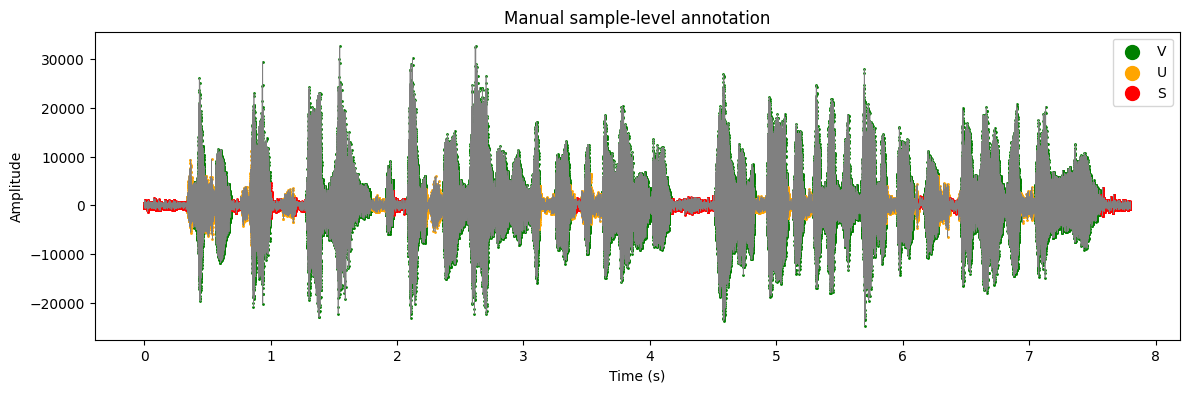

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def expand_segments_to_samples(manual_segments, sig, rate):
    # Converts (start_sec, end_sec, label) segments into a per-sample label array
    # of the same length as sig
    #####################################
    manual_sample_labels = np.empty(len(sig),dtype='<U1')
    for start,end,label in manual_segments:
        start_sample = int(round(start*rate))
        end_sample = int(round(end*rate))
        end_sample = min(end_sample,len(sig))
        manual_sample_labels[start_sample:end_sample] = label
    #####################################
    return manual_sample_labels

manual_sample_labels = expand_segments_to_samples(manual_segments, sig, rate)

#####################################
# Plot sig with manual_sample_labels overlaid (e.g. one color per V/U/S) as a
# sanity check on your annotation
# Complete the code
time_axis = np.arange(len(sig)) / rate

plt.figure(figsize=(14, 4))
plt.plot(time_axis, sig, color='gray', linewidth=0.5)

colors = {'V': 'green', 'U': 'orange', 'S': 'red'}
for lab, color in colors.items():
    mask = manual_sample_labels == lab
    plt.scatter(time_axis[mask], sig[mask], color=color, s=1, label=lab)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Manual sample-level annotation')
plt.legend(markerscale=10)
plt.show()


#####################################


#### 3) Frame the speech signal

A figure is included to demonstrate the concept of framing the speech signal. It depicts how the speech signal is divided into multiple frames, each with a size of 400 samples and a frameshift of 160 samples. Complete the "FrameSig" function to replicate this process.

<img src="https://raw.githubusercontent.com/Sreeakanth/SpeechSystems/main/Framing.png" width="1853px" height="991px">


In [6]:
def FrameSig(input, frameSize=0.025, frameShift=0.010, window='hamming'):

    frame_length = int(round(frameSize * rate))
    frame_step = int(round(frameShift * rate))

    signal_length = len(input)

    num_frames = 1 + (signal_length - frame_length) // frame_step

    frames = np.zeros((num_frames, frame_length))

    for i in range(num_frames):
        start = i * frame_step
        frames[i] = input[start:start + frame_length]

    if window == 'hamming':
        win = np.hamming(frame_length)
        frames = frames * win

    return frames

#### 4) Voiced / Unvoiced activity detection

Compute the autocorrelation sequence of a mean-subtracted frame $x[n]$ as follows:

$$r_{xx}[k] = \frac{1}{r_{xx}[0]}\sum_{n=0}^{N} x[n]x[n+k] \;\;\;\; k = ...,-2,-1,0,1,2,...$$

The figure below illustrates the autocorrelation sequence for both voiced and unvoiced frames. It demonstrates that the voiced/unvoiced decision can be made based on the strength of the second peak in the autocorrelation sequence. A frame is classified as voiced if the strength of the second peak exceeds a certain threshold; otherwise, it is classified as unvoiced. For voiced frames, the fundamental frequency ($F_{0}$) period can be determined from the location of this second peak. Note that the threshold is a hyperparameter that must be optimized empirically. Write a code to complete this task. Note that identifying the location of the second peak in the autocorrelation sequence is challenging due to factors such as noise, variations in signal strength, and potential overlapping peaks. To accurately detect the valid second peak, you need to incorporate several constraints in your code, including:

1. Ensure the second peak is distinct and sufficiently higher than neighboring peaks.
2. Verify that the second peak occurs at a reasonable distance from the first peak, reflecting typical $F_{0}$.
3. Confirm that the peak's position is consistent across different frames to avoid misclassification.

Incorporate these meaningful constraints into your code to effectively identify the valid second peak and complete the task.

<img src="https://raw.githubusercontent.com/Sreeakanth/SpeechSystems/master/VoicedUnvoiced.png" width="800px" height="400px">


In [7]:
import numpy as np

def AutoCorrelation(frame):
    # Takes frame as input and returns auto correlation sequence of the frame
    '''
    Input = (1,samplingRate*frameDuration)
    Output = (samplingRate*frameDuration) # auto correlation sequence is symmetric
    '''
    #####################################
    x = frame - np.mean(frame)                    # mean subtraction
    result = np.correlate(x, x, mode='full')       # full cross-correlation, length 2N-1
    mid = len(result) // 2
    Rxx = result[mid:]                             # keep lag 0 and positive lags (symmetric, so this is enough) -> length N
    Rxx = Rxx / Rxx[0]
    return Rxx

    #####################################

MIN_F0 = 60
MAX_F0 = 400

def find_second_peak(Rxx, rate, min_f0=MIN_F0, max_f0=MAX_F0):
    min_lag = int(rate / max_f0)                   # shortest plausible period (highest F0)
    max_lag = min(int(rate / min_f0), len(Rxx) - 1) # longest plausible period (lowest F0)
    if min_lag >= max_lag:
        return None, 0.0
    region = Rxx[min_lag:max_lag + 1]
    peak_idx_rel = np.argmax(region)                # tallest point within the allowed lag range
    peak_lag = min_lag + peak_idx_rel
    return peak_lag, Rxx[peak_lag]


def get_f0(Rxx, rate):
    # Extract fundamental frequency from autocorrelation

    peak_lag, peak_val = find_second_peak(Rxx, rate)

    if peak_lag is None:
        return 0

    F0 = rate / peak_lag

    return F0

def get_voiced(Rxx, rate, threshold):
    # Returns voiced/unvoiced decision from autocorrelation

    peak_lag, peak_val = find_second_peak(Rxx, rate)

    if peak_lag is None:
        return False

    voiced = peak_val > threshold

    return voiced

def VoicedVSUnvoiced(frame, threshold, rate=16000):
    # Given a frame , returns whether the frame is voiced or unvoiced
    # If the frame is voiced, The code returns the F0 of the voiced frame
    # If the frame is unvoiced. The code returns some constant ( dummy ) value as F0 ( It will help in filtering out unvoiced frames )
    '''
    Input = signal frame (or) N number of frames
    Output = Binary flag indicating voicing decision and the F0 of the voiced frames
    '''
    Rxx = AutoCorrelation(frame)                     # Auto correlation function
    voiced = get_voiced(Rxx, rate=rate, threshold=threshold)

    ##################################### Set fundamental frequency of unvoiced frames as zero
    if voiced:
        F0 = get_f0(Rxx, rate=rate)                  # extracts fundamental frequency of voiced frames
    else:
        F0 = 0                                       # dummy value for unvoiced frames
    #####################################

    return voiced, F0


#### 5) Unvoiced / Silent Classification

Compute the energy of frames that are not classified as voiced, $E = \sum\limits_{n} | x[n] |^2$. Compare this energy with a threshold. If the energy exceeds a certain threshold, classify the frame as unvoiced. Note that the threshold is a hyperparameter that should be optimized empirically. If the energy is below the threshold, classify the frame as silent.


In [8]:
import numpy as np

def Energy(frame):
    # Returns the energy of the signal
    E = np.sum(np.abs(frame) ** 2)
    return E

def SilenceVSUnvoiced(unvoiced_frame, threshold):
    # Given an unvoiced frame, returns whether the unvoiced frame contains speech
    # information (fricatives or a few stop consonants etc) or silence
    energy = Energy(unvoiced_frame)
    ####################
    if energy > threshold:
        decision = 'U'   # enough energy -> real (unvoiced) speech sound
    else:
        decision = 'S'   # too little energy -> silence
    ####################
    return decision

#### Run the pipeline

Put the functions above to work: frame your (already-loaded) `sig`, then run your voiced/unvoiced and silent/unvoiced classifiers on it.


In [9]:
import numpy as np

sig = sig - np.mean(sig)

frameSize = 0.025
frameShift = 0.010
windowing = 'hamming'
Frames = FrameSig(sig, frameSize, frameShift, windowing)

FrameEnergies = np.array([Energy(frame) for frame in Frames])  # needed later for empirical threshold

PeakThreshold = 0.44
VoicedDecision = []
EstimatedF0 = []
for frame in Frames:
    v, f0 = VoicedVSUnvoiced(frame, PeakThreshold, rate=rate)
    VoicedDecision.append(v)
    EstimatedF0.append(f0)
VoicedDecision = np.array(VoicedDecision)
EstimatedF0 = np.array(EstimatedF0)

UnvoicedFrames = Frames[~VoicedDecision]

#### 6) Evaluation against your manual ground truth

Your annotation from Section 2 is at the sample level, while your classifier's output is at the frame level, so the two have to be brought onto a common grid before anything can be scored.

**Sample labels $\rightarrow$ frame labels.** Give each frame the label held by the most of its samples — the dominant class — breaking ties in the order $V > U > S$. Use the same `frameSize`, `frameShift` and `rate` you passed to `FrameSig`, so that the labels line up with `Frames`.

**Score.** Build the $3 \times 3$ confusion matrix over the classes $(V, U, S)$, with rows = your manual label and columns = your algorithm's label, and report the overall frame-level accuracy:

$$\text{accuracy} = \frac{\text{tr}(C)}{\sum_{i,j} C[i,j]}$$

In your report (Section 9), discuss a few frames where your algorithm disagreed with your manual label, quoting the $r_{xx}$ and energy values you computed for those frames.


In [10]:
import numpy as np

CLASSES = ('V', 'U', 'S')   # also the tie-breaking priority order: V > U > S

def sample_labels_to_frame_labels(manual_sample_labels, frameSize, frameShift, rate, num_frames):
    '''
    Collapses the sample-level annotation from Section 2 onto the frame grid used by FrameSig.
    Each frame takes the label held by most of its samples, with ties broken in CLASSES order.
    '''
    #####################################
    frame_length = int(round(frameSize * rate))
    frame_step   = int(round(frameShift * rate))

    manual_frame_labels = []
    for i in range(num_frames):
        start = i * frame_step
        end = start + frame_length
        window_labels = manual_sample_labels[start:end]

        counts = {c: np.sum(window_labels == c) for c in CLASSES}
        max_count = max(counts.values())
        # among classes tied for the max count, pick the one earliest in CLASSES (V > U > S)
        winner = next(c for c in CLASSES if counts[c] == max_count)

        manual_frame_labels.append(winner)
    #####################################
    return np.array(manual_frame_labels)


manual_frame_labels = sample_labels_to_frame_labels(
    manual_sample_labels, frameSize, frameShift, rate, Frames.shape[0])



assert len(manual_frame_labels) == Frames.shape[0], \
    "frame-label grid does not match Frames - check your framing convention"

In [11]:
EnergyThreshold = 82711864.40677966

SilenceVSUnvoicedDecision = []
for frame in UnvoicedFrames:
    label = SilenceVSUnvoiced(frame, EnergyThreshold)
    SilenceVSUnvoicedDecision.append(label)
SilenceVSUnvoicedDecision = np.array(SilenceVSUnvoicedDecision)

In [12]:

import numpy as np

def frame_algo_labels(VoicedDecision, SilenceVSUnvoicedDecision):
    '''
    Combines your two cascaded decisions into a single label per frame ('V' / 'U' / 'S').
    '''
    #####################################
    algo_labels = np.empty(len(VoicedDecision), dtype='<U1')
    algo_labels[VoicedDecision] = 'V'                          # voiced frames get 'V'
    algo_labels[~VoicedDecision] = SilenceVSUnvoicedDecision    # remaining frames get 'U' or 'S', in the same order they were computed
    #####################################
    return algo_labels


def confusion_matrix(true_labels, pred_labels, classes=CLASSES):
    # Returns a len(classes) x len(classes) integer matrix,
    # rows = manual (true) label, columns = algorithm (predicted) label
    #####################################
    n = len(classes)
    C = np.zeros((n, n), dtype=int)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(true_labels, pred_labels):
        C[class_to_idx[t], class_to_idx[p]] += 1
    #####################################
    return C


def accuracy(C):
    # trace(C) / sum(C)
    #####################################
    return np.trace(C) / np.sum(C)
    #####################################


algo_labels = frame_algo_labels(VoicedDecision, SilenceVSUnvoicedDecision)
C = confusion_matrix(manual_frame_labels, algo_labels)

print("Confusion matrix (rows = manual, cols = algorithm), classes =", CLASSES)
print(C)
print("accuracy: %.3f" % accuracy(C))

Confusion matrix (rows = manual, cols = algorithm), classes = ('V', 'U', 'S')
[[487  10   2]
 [ 26  82  31]
 [ 23  10 107]]
accuracy: 0.869


In [13]:
'''import numpy as np

def run_pipeline(Frames, rate, peak_threshold, energy_threshold):
    voiced_decision, est_f0 = [], []
    for frame in Frames:
        v, f0 = VoicedVSUnvoiced(frame, peak_threshold, rate=rate)
        voiced_decision.append(v)
        est_f0.append(f0)
    voiced_decision = np.array(voiced_decision)
    unvoiced_frames = Frames[~voiced_decision]
    silence_vs_unvoiced = np.array([SilenceVSUnvoiced(f, energy_threshold) for f in unvoiced_frames])
    algo_labels = np.empty(len(voiced_decision), dtype='<U1')
    algo_labels[voiced_decision] = 'V'
    algo_labels[~voiced_decision] = silence_vs_unvoiced
    return algo_labels

# Keep PeakThreshold fixed at 0.4 and sweep only the energy threshold.
peak_thresholds = np.array([0.4])
energy_thresholds = np.linspace(40e6, 100e6, 60)

results = []
for pt in peak_thresholds:
    for et in energy_thresholds:
        algo_labels = run_pipeline(Frames, rate, pt, et)
        C = confusion_matrix(manual_frame_labels, algo_labels)
        results.append((accuracy(C), pt, et, C))

results.sort(key=lambda r: -r[0])
print("Top 8:")
for acc, pt, et, C in results[:8]:
    print(f"acc={acc:.4f}  peak={pt:.3f}  energy={et:.3e}")

best_acc, best_pt, best_et, best_C = results[0]
print()
print("BEST:", best_acc, best_pt, best_et)
print(best_C)'''

'import numpy as np\n\ndef run_pipeline(Frames, rate, peak_threshold, energy_threshold):\n    voiced_decision, est_f0 = [], []\n    for frame in Frames:\n        v, f0 = VoicedVSUnvoiced(frame, peak_threshold, rate=rate)\n        voiced_decision.append(v)\n        est_f0.append(f0)\n    voiced_decision = np.array(voiced_decision)\n    unvoiced_frames = Frames[~voiced_decision]\n    silence_vs_unvoiced = np.array([SilenceVSUnvoiced(f, energy_threshold) for f in unvoiced_frames])\n    algo_labels = np.empty(len(voiced_decision), dtype=\'<U1\')\n    algo_labels[voiced_decision] = \'V\'\n    algo_labels[~voiced_decision] = silence_vs_unvoiced\n    return algo_labels\n\n# Keep PeakThreshold fixed at 0.4 and sweep only the energy threshold.\npeak_thresholds = np.array([0.4])\nenergy_thresholds = np.linspace(40e6, 100e6, 60)\n\nresults = []\nfor pt in peak_thresholds:\n    for et in energy_thresholds:\n        algo_labels = run_pipeline(Frames, rate, pt, et)\n        C = confusion_matrix(manu

#### 7) Illustrations

This part of the PA expects you to tag the speech signal with voiced, unvoiced, and silent labels. And also plot the $F_{0}$ contour ( tracking the $F_{0}$ across the frames ) in the voiced regions. You can follow these steps to complete this

- Create a plot with two subplots.
- In the first subplot, display the time-domain waveform of the speech signal and differentiate the voiced, unvoiced, and silent frames using distinct colors.
- In the second subplot, display the fundamental frequency of the voiced frames.
- You are requested to show the results with the following speech signal.

[link to example speech signal](https://drive.google.com/file/d/1jRrMqrz4NR8x1F6-sbk2I5wSMcti7jD5/view?usp=sharing)


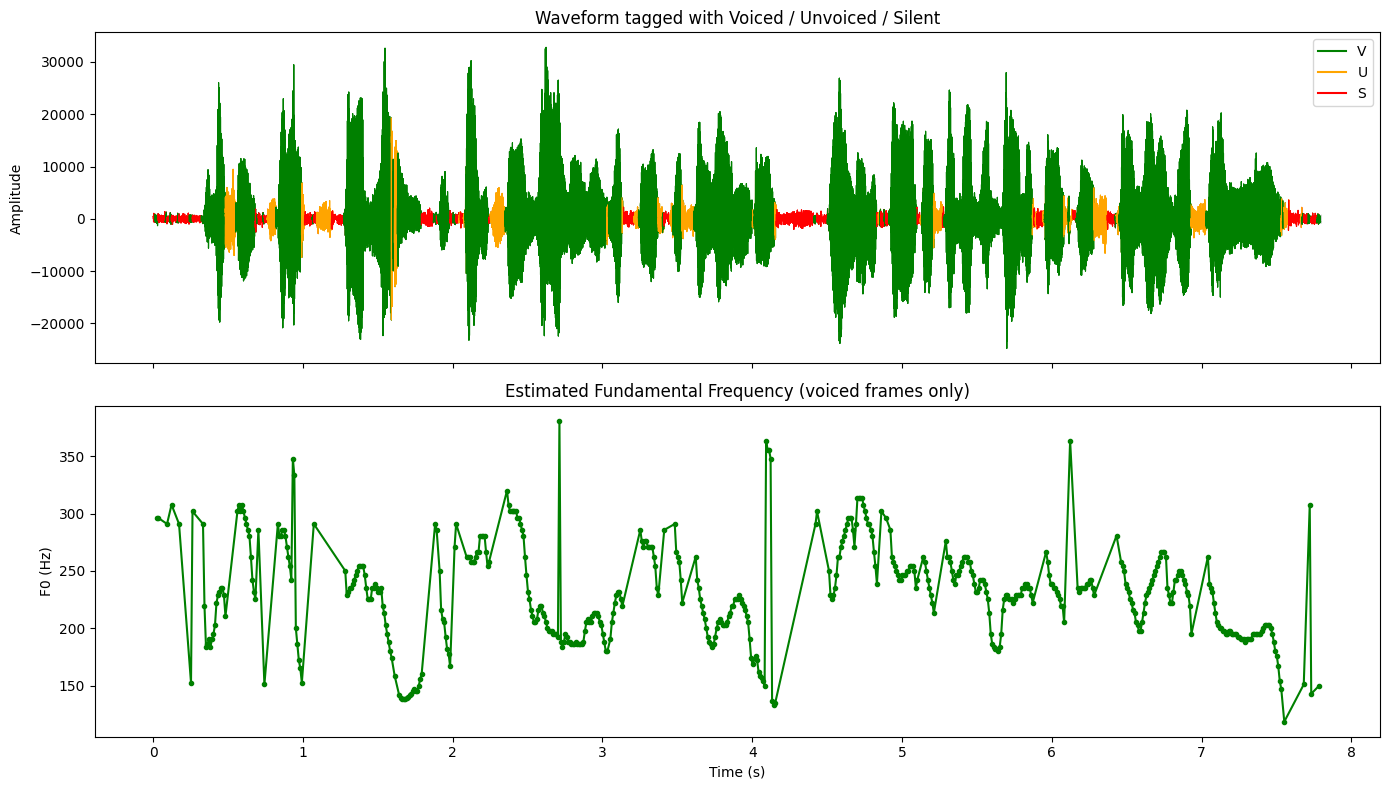

In [14]:
import matplotlib.pyplot as plt
import numpy as np

###################################
frame_length = int(round(frameSize * rate))
frame_step   = int(round(frameShift * rate))
num_frames   = Frames.shape[0]

time_axis = np.arange(len(sig)) / rate           # time for every sample in sig
frame_times = (np.arange(num_frames) * frame_step + frame_length / 2) / rate  # time at CENTER of each frame

colors = {'V': 'green', 'U': 'orange', 'S': 'red'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ---- Subplot 1: waveform colored by V/U/S ----
ax = axes[0]
ax.plot(time_axis, sig, color='lightgray', linewidth=0.5, zorder=1)  # faint full waveform as backdrop

for i in range(num_frames):
    start = i * frame_step
    end = min(start + frame_length, len(sig))
    lab = algo_labels[i]
    ax.plot(time_axis[start:end], sig[start:end], color=colors[lab], linewidth=0.8, zorder=2)

# legend (manual, since we plotted many small segments)
for lab, c in colors.items():
    ax.plot([], [], color=c, label=lab)
ax.set_ylabel('Amplitude')
ax.set_title('Waveform tagged with Voiced / Unvoiced / Silent')
ax.legend(loc='upper right')

# ---- Subplot 2: F0 contour over voiced frames ----
ax2 = axes[1]
voiced_mask = (algo_labels == 'V')
ax2.plot(frame_times[voiced_mask], EstimatedF0[voiced_mask], 'o-', color='green', markersize=3)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('F0 (Hz)')
ax2.set_title('Estimated Fundamental Frequency (voiced frames only)')

plt.tight_layout()
plt.show()
###################################

#### 8) Benchmark evaluation on the Keele pitch database

Section 6 scored your system against your own annotation of one recording. Here you score it on a standard corpus whose reference comes from a laryngograph: the Keele pitch database (Plante, Meyer & Ainsworth, Eurospeech '95) - download it from [here](https://drive.google.com/drive/folders/1r8IZ-WnEEF-dFhgEFBv0bfeSQ1O7CBaN?usp=drive_link), and keep it in your drive for evaluation. Ten speakers — five female (`f1nw0000` … `f5nw0000`) and five male (`m1nw0000` … `m5nw0000`) — read *The North Wind and the Sun*, about 5.6 minutes in all. Each speaker folder holds:

| file | contents |
| --- | --- |
| `signal.wav` | microphone signal, 20 kHz |
| `laryngograph.wav` | simultaneous laryngograph signal, 20 kHz |
| `f0.npy` | reference $F_{0}$ in Hz, one value per 10 ms, 0 where unvoiced |
| `voicing.npy` | `1` voiced, `0` unvoiced |

Two constraints on your analysis. The sampling rate is **20 kHz, not 16 kHz**, so nothing may hardcode a rate. The reference sits on a 10 ms grid starting at $t = 0$, so use `frameShift = 0.010` and align your frame $i$ with reference entry $i$; `frameSize = 0.0256` matches the window the reference itself used.

The evaluation has two parts, because your system makes two different decisions. **8.1** asks whether each frame is voiced. **8.2** asks, for the frames that are, how accurate the $F_{0}$ value is.

*The Keele reference separates only voiced from unvoiced, so this section checks the voicing decision from Section 4. The three-way voiced / unvoiced / silent decision is checked in Section 6 against your own annotation.*


In [15]:
######################## Load the Keele dataset ########################
import os
import urllib.request
import zipfile

extract_to = r"C:\Users\aanuu\Downloads\Keele_Database"
DATASET_DIR = os.path.join(extract_to, "Keele_Database")

speakers = sorted(d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d)))
print("%d speakers:" % len(speakers), speakers)


10 speakers: ['f1nw0000', 'f2nw0000', 'f3nw0000', 'f4nw0000', 'f5nw0000', 'm1nw0000', 'm2nw0000', 'm3nw0000', 'm4nw0000', 'm5nw0000']


In [16]:
import numpy as np
import soundfile as sf
import os

def load_keele_speaker(speaker, dataset_dir=DATASET_DIR):
    d = os.path.join(dataset_dir, speaker)
    sig, rate = sf.read(os.path.join(d, "signal.wav"))
    ref_f0 = np.load(os.path.join(d, "f0.npy"))
    voicing = np.load(os.path.join(d, "voicing.npy"))
    return sig, rate, ref_f0, voicing


def run_pipeline(sig, rate, frameSize, frameShift, windowing, PeakThreshold, EnergyThreshold):
    '''
    Wraps Sections 3-5 into one reusable call so it can be run over each speaker.
    Returns one estimated F0 per frame: the estimate in Hz for frames your system
    calls voiced, and 0 for frames it calls unvoiced or silent.
    '''
    #####################################
    sig = sig - np.mean(sig)
    Frames = FrameSig(sig, frameSize, frameShift, windowing)

    est_f0 = np.zeros(Frames.shape[0])
    for i, frame in enumerate(Frames):
        voiced, f0 = VoicedVSUnvoiced(frame, PeakThreshold, rate=rate)
        if voiced:
            est_f0[i] = f0
        else:
            # not voiced -- optionally could distinguish U vs S here via SilenceVSUnvoiced,
            # but Keele reference doesn't need that distinction; est_f0 stays 0
            est_f0[i] = 0.0
    #####################################
    return est_f0


def align(ref_f0, voicing, est_f0):
    #####################################
    n = min(len(ref_f0), len(voicing), len(est_f0))
    ref_f0 = ref_f0[:n]
    voicing = voicing[:n]
    est_f0 = est_f0[:n]
    #####################################
    return ref_f0, voicing, est_f0

##### 8.1 Voicing detection

Collapse your three-way output to voiced against everything else, and compare it with `voicing`. There are two ways to be wrong and they are not symmetric, so report both.

**Miss rate** — the proportion of genuinely voiced frames your system failed to find, where the autocorrelation had a real second peak but it fell below `PeakThreshold`:

$$P_{\text{miss}} = \frac{\#\{i : \text{ref voiced}, \; \text{est unvoiced}\}}{\#\{i : \text{ref voiced}\}}$$

**False alarm rate** — the proportion of genuinely unvoiced frames your system claimed were voiced, usually from a spurious peak in noise or from a voiced neighbour bleeding into the analysis window:

$$P_{\text{fa}} = \frac{\#\{i : \text{ref unvoiced}, \; \text{est voiced}\}}{\#\{i : \text{ref unvoiced}\}}$$

Report the pair rather than a single combined figure, because `PeakThreshold` trades one directly against the other: raise it and misses go up while false alarms go down. A single number hides which way your threshold is leaning. A miss is the more damaging of the two here, since a frame you call unvoiced yields no $F_{0}$ at all and so cannot contribute to 8.2.


In [17]:
import numpy as np

def voicing_scores(voicing, est_f0):
    '''
    voicing : reference, 1 voiced / 0 unvoiced
    est_f0  : your per-frame estimate, > 0 where your system says voiced

    Returns P_miss, P_fa
    '''
    #####################################
    voicing = np.asarray(voicing).astype(bool)
    est_voiced = est_f0 > 0

    ref_voiced_count = np.sum(voicing)
    ref_unvoiced_count = np.sum(~voicing)

    misses = np.sum(voicing & ~est_voiced)          # ref says voiced, you said not-voiced
    false_alarms = np.sum(~voicing & est_voiced)     # ref says unvoiced, you said voiced

    P_miss = misses / ref_voiced_count if ref_voiced_count > 0 else 0.0
    P_fa   = false_alarms / ref_unvoiced_count if ref_unvoiced_count > 0 else 0.0
    #####################################
    return P_miss, P_fa

##### 8.2 $F_{0}$ estimation

How accurate are the $F_{0}$ values themselves? This is separate from 8.1 — a system can find every voiced frame and still put the pitch an octave out.

Both metrics are computed only over the frames that **both** you and the reference call voiced, the only frames where two $F_{0}$ values exist to compare. Write $r_i$ for the reference and $\hat{f}_i$ for your estimate, over that set $\mathcal{B}$.

**Gross Pitch Error** — the proportion of those frames where the estimate is badly wrong, at the conventional 20% tolerance:

$$\text{GPE} = \frac{\#\{i \in \mathcal{B} : |\hat{f}_i - r_i| > 0.2 \, r_i\}}{|\mathcal{B}|}$$

The 20% figure catches octave errors while ignoring ordinary jitter: doubling the pitch is a $+100\%$ error and halving it $-50\%$, both far outside the tolerance, while a few percent of estimation noise is not. GPE is therefore mostly a count of octave and sub-harmonic mistakes — the characteristic failure of second-peak picking.

**Fine Pitch Error** — how precise the estimate is when it is not grossly wrong: the standard deviation, in percent, of the relative error over the frames of $\mathcal{B}$ that are not gross errors.

$$\text{FPE} = \operatorname{std}\left(100 \cdot \frac{\hat{f}_i - r_i}{r_i}\right)$$

The two separate because they have different causes and different fixes. GPE is about which peak you pick; FPE is about how precisely you locate it, and since the lag is a whole number of samples, the resolution at 20 kHz is already coarse near 200 Hz.

**For your report:**

- Give $P_{\text{miss}}$, $P_{\text{fa}}$, GPE and FPE per speaker, and pooled over the corpus.
- Compare your male and female averages. Which is harder for an autocorrelation tracker, and how does that follow from your window length?
- Plot $\hat{f}_i / r_i$ for your gross errors. Are they concentrated near 2 or near 0.5? Explain what in the autocorrelation sequence produces each.


In [18]:
import numpy as np

GPE_TOLERANCE = 0.20

def gross_pitch_error(ref_f0, voicing, est_f0):
    #####################################
    voicing = np.asarray(voicing).astype(bool)
    est_voiced = est_f0 > 0
    both_voiced = voicing & est_voiced          # set B: both reference and system say voiced

    r = ref_f0[both_voiced]
    f = est_f0[both_voiced]

    if len(r) == 0:
        return np.nan

    rel_error = np.abs(f - r) / r
    is_gross = rel_error > GPE_TOLERANCE

    GPE = np.sum(is_gross) / len(r)
    #####################################
    return GPE

def fine_pitch_error(ref_f0, voicing, est_f0):
    #####################################
    voicing = np.asarray(voicing).astype(bool)
    est_voiced = est_f0 > 0
    both_voiced = voicing & est_voiced

    r = ref_f0[both_voiced]
    f = est_f0[both_voiced]

    if len(r) == 0:
        return np.nan

    rel_error_pct = 100 * (f - r) / r
    is_gross = np.abs(f - r) / r > GPE_TOLERANCE

    fine_errors = rel_error_pct[~is_gross]      # only the NON-gross frames

    FPE = np.std(fine_errors) if len(fine_errors) > 0 else np.nan
    #####################################
    return FPE

In [19]:
import numpy as np

keele_frameSize  = 0.0256
keele_frameShift = 0.010

print("%-10s %8s %8s %8s %8s" % ("speaker", "P_miss", "P_fa", "GPE", "FPE"))

all_ref_f0 = []
all_voicing = []
all_est_f0 = []
speaker_gender = {}   # speaker -> 'f' or 'm'

for speaker in speakers:
    sig, rate, ref_f0, voicing = load_keele_speaker(speaker)
    est_f0 = run_pipeline(sig, rate, keele_frameSize, keele_frameShift,
                          windowing, PeakThreshold, EnergyThreshold)
    ref_f0, voicing, est_f0 = align(ref_f0, voicing, est_f0)

    P_miss, P_fa = voicing_scores(voicing, est_f0)
    GPE = gross_pitch_error(ref_f0, voicing, est_f0)
    FPE = fine_pitch_error(ref_f0, voicing, est_f0)
    print("%-10s %7.2f%% %7.2f%% %7.2f%% %7.2f%%" % (
        speaker, 100*P_miss, 100*P_fa, 100*GPE, FPE))

    # stash this speaker's frames for pooling later
    all_ref_f0.append(ref_f0)
    all_voicing.append(voicing)
    all_est_f0.append(est_f0)
    speaker_gender[speaker] = speaker[0]   # 'f' or 'm', from the speaker id prefix

#####################################
# Pool the metrics over the corpus, and report the female and male averages
# separately (see the report questions above)
#####################################

# ---- Pool ALL speakers together ----
pooled_ref_f0  = np.concatenate(all_ref_f0)
pooled_voicing = np.concatenate(all_voicing)
pooled_est_f0  = np.concatenate(all_est_f0)

P_miss_all, P_fa_all = voicing_scores(pooled_voicing, pooled_est_f0)
GPE_all = gross_pitch_error(pooled_ref_f0, pooled_voicing, pooled_est_f0)
FPE_all = fine_pitch_error(pooled_ref_f0, pooled_voicing, pooled_est_f0)

print()
print("POOLED OVER ALL 10 SPEAKERS:")
print("%-10s %7.2f%% %7.2f%% %7.2f%% %7.2f%%" % (
    "ALL", 100*P_miss_all, 100*P_fa_all, 100*GPE_all, FPE_all))

# ---- Average the five speaker metrics separately by gender ----
speaker_results = []

for i, speaker in enumerate(speakers):
    P_miss, P_fa = voicing_scores(all_voicing[i], all_est_f0[i])
    GPE = gross_pitch_error(all_ref_f0[i], all_voicing[i], all_est_f0[i])
    FPE = fine_pitch_error(all_ref_f0[i], all_voicing[i], all_est_f0[i])

    speaker_results.append((speaker, speaker_gender[speaker],
                            P_miss, P_fa, GPE, FPE))

for gender, label in [('f', 'FEMALE'), ('m', 'MALE')]:
    results = [x for x in speaker_results if x[1] == gender]

    avg_P_miss = np.mean([x[2] for x in results])
    avg_P_fa   = np.mean([x[3] for x in results])
    avg_GPE    = np.mean([x[4] for x in results])
    avg_FPE    = np.mean([x[5] for x in results])

    print("%-10s %7.2f%% %7.2f%% %7.2f%% %7.2f%%" % (
        label,
        100*avg_P_miss,
        100*avg_P_fa,
        100*avg_GPE,
        avg_FPE
    ))

speaker      P_miss     P_fa      GPE      FPE
f1nw0000     10.19%   22.04%    2.76%    2.57%
f2nw0000      6.26%   23.81%    2.80%    2.56%
f3nw0000     10.13%   36.48%    2.51%    2.49%
f4nw0000     11.65%   29.74%    3.95%    3.02%
f5nw0000      5.27%   41.49%    1.65%    2.60%
m1nw0000     70.24%   18.83%   17.19%    1.38%
m2nw0000     29.31%   17.69%    5.22%    3.40%
m3nw0000     15.74%   20.97%    1.54%    2.43%
m4nw0000     88.67%   23.05%    4.89%    3.19%
m5nw0000     59.44%   18.19%    7.74%    2.55%

POOLED OVER ALL 10 SPEAKERS:
ALL          31.36%   25.22%    3.87%    2.68%
FEMALE        8.70%   30.71%    2.74%    2.65%
MALE         52.68%   19.75%    7.32%    2.59%


### Observations

- For all 10 speakers, the system gives a **31.36% miss rate, 25.22% false-alarm rate, 3.87% GPE, and 2.68% FPE**.

- The system performs better for female speakers. The miss rate is **8.70%** for females, compared with **52.68%** for males. The GPE is also lower for females (**2.74%**) than for males (**7.32%**).

- Male speech is harder to detect using autocorrelation because male voices generally have lower $F_0$. Therefore, fewer pitch periods are present in the fixed **25.6 ms** window, making the autocorrelation peak less clear.

- The FPE is almost the same for females (**2.65%**) and males (**2.59%**). This means that when the system detects the correct pitch, the $F_0$ estimate is reasonably accurate for both.

- The gross-error plot shows that most of the errors are close to a ratio of **2**, while fewer errors occur near **0.5**.

- A ratio of **2** means that the estimated pitch is about twice the reference pitch, which is an **octave-up error**. This happens when the system selects a lag close to $T_0/2$ instead of the actual period $T_0$.

- A ratio of **0.5** means that the estimated pitch is about half the reference pitch, which is an **octave-down error**. This happens when the system selects a lag close to $2T_0$.

- Hence, in this experiment, **octave-up errors are more common**, suggesting that the tracker more often selects a shorter autocorrelation lag than the actual fundamental period.

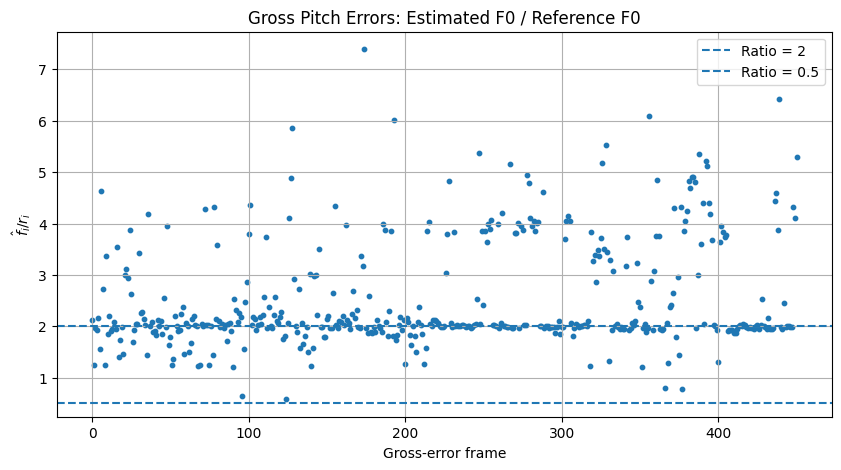

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Collect F0 ratio for all gross-error frames
gross_ratios = []

for i in range(len(all_ref_f0)):
    ref = all_ref_f0[i]
    est = all_est_f0[i]
    voi = all_voicing[i].astype(bool)

    both_voiced = voi & (est > 0)

    r = ref[both_voiced]
    f = est[both_voiced]

    rel_error = np.abs(f - r) / r
    gross = rel_error > GPE_TOLERANCE

    ratios = f[gross] / r[gross]
    gross_ratios.extend(ratios)

gross_ratios = np.array(gross_ratios)

plt.figure(figsize=(10, 5))
plt.scatter(
    np.arange(len(gross_ratios)),
    gross_ratios,
    s=10
)

plt.axhline(2.0, linestyle='--', label='Ratio = 2')
plt.axhline(0.5, linestyle='--', label='Ratio = 0.5')

plt.xlabel('Gross-error frame')
plt.ylabel(r'$\hat{f}_i / r_i$')
plt.title('Gross Pitch Errors: Estimated F0 / Reference F0')
plt.legend()
plt.grid(True)
plt.show()

#### 9) Study of submodules in voice activity detection and $F_{0}$ estimation

1. Examine how frame size impacts voice activity detection and fundamental frequency estimation.
    - Try using different frame sizes and observe how they affect the quality of the tags.
    - Quantify this rather than eyeballing it: re-run the Keele evaluation from Section 8 at each frame size and plot the miss rate, false alarm rate and Gross Pitch Error against frame size.
2. Examine the effects of preprocessing the waveform, such as mean subtraction and max normalization, on the analysis.
3. Plot and analyze the $F_{0}$ contour for the 'sa-pa-sa' vocals.

    [link to 'sa-pa-sa' vocals](https://drive.google.com/file/d/11UkMo8c4qK1gxxtMN2QycooHVyXizK7U/view?usp=sharing)

4. Why the autocorrelation function rolls off with lag? what other methods can be employed to prevent it?


frameSize=0.0100s  P_miss=93.14%  P_fa=0.82%  GPE=27.60%
frameSize=0.0150s  P_miss=57.49%  P_fa=3.57%  GPE=5.65%
frameSize=0.0200s  P_miss=44.99%  P_fa=17.32%  GPE=4.30%
frameSize=0.0256s  P_miss=31.36%  P_fa=25.22%  GPE=3.87%
frameSize=0.0300s  P_miss=23.15%  P_fa=29.01%  GPE=3.38%
frameSize=0.0400s  P_miss=15.13%  P_fa=34.09%  GPE=3.32%
frameSize=0.0500s  P_miss=13.87%  P_fa=37.38%  GPE=3.61%


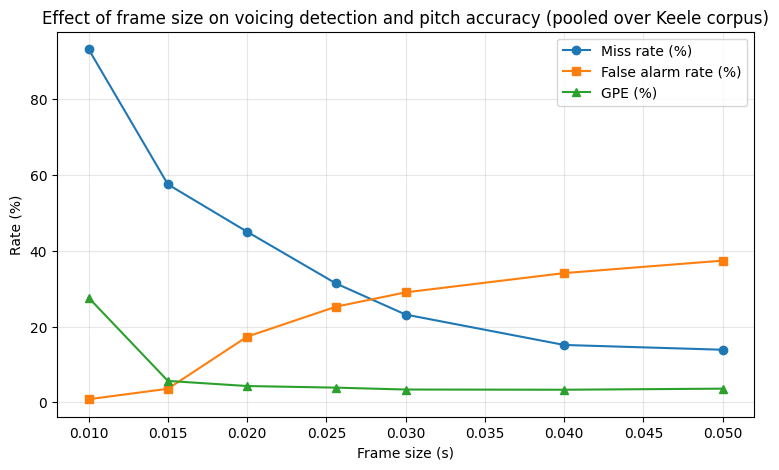

In [21]:
import numpy as np
import matplotlib.pyplot as plt

###################################
frame_sizes_to_test = [0.010, 0.015, 0.020, 0.0256, 0.030, 0.040, 0.050]  # seconds
keele_frameShift = 0.010   # keep frame shift fixed, matching the reference grid

miss_rates = []
fa_rates = []
gpe_rates = []

for fsize in frame_sizes_to_test:
    all_ref_f0, all_voicing, all_est_f0 = [], [], []
    for speaker in speakers:
        sig, rate, ref_f0, voicing = load_keele_speaker(speaker)
        est_f0 = run_pipeline(sig, rate, fsize, keele_frameShift,
                              windowing, PeakThreshold, EnergyThreshold)
        ref_f0_a, voicing_a, est_f0_a = align(ref_f0, voicing, est_f0)
        all_ref_f0.append(ref_f0_a)
        all_voicing.append(voicing_a)
        all_est_f0.append(est_f0_a)

    pooled_ref_f0  = np.concatenate(all_ref_f0)
    pooled_voicing = np.concatenate(all_voicing)
    pooled_est_f0  = np.concatenate(all_est_f0)

    P_miss, P_fa = voicing_scores(pooled_voicing, pooled_est_f0)
    GPE = gross_pitch_error(pooled_ref_f0, pooled_voicing, pooled_est_f0)

    miss_rates.append(100*P_miss)
    fa_rates.append(100*P_fa)
    gpe_rates.append(100*GPE)

    print(f"frameSize={fsize:.4f}s  P_miss={100*P_miss:.2f}%  P_fa={100*P_fa:.2f}%  GPE={100*GPE:.2f}%")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(frame_sizes_to_test, miss_rates, 'o-', label='Miss rate (%)')
ax.plot(frame_sizes_to_test, fa_rates, 's-', label='False alarm rate (%)')
ax.plot(frame_sizes_to_test, gpe_rates, '^-', label='GPE (%)')
ax.set_xlabel('Frame size (s)')
ax.set_ylabel('Rate (%)')
ax.set_title('Effect of frame size on voicing detection and pitch accuracy (pooled over Keele corpus)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
###################################

### 9.1 Effect of Frame Size

- Frame size has a noticeable effect on both voicing detection and $F_0$ estimation.

- At **10 ms**, the performance is poor, with a **93.14% miss rate** and **27.60% GPE**. This is because the short frame does not contain enough pitch-period information.

- As the frame size increases, the **miss rate decreases** because the autocorrelation gets more information from the signal and can detect periodicity more easily.

- On the other hand, the **false-alarm rate increases**, from **0.82% at 10 ms** to **37.38% at 50 ms**. A longer frame can contain parts of nearby voiced regions, causing an unvoiced frame to be detected as voiced.

- The GPE also decreases with increasing frame size, from **27.60% at 10 ms** to around **3–4%** for larger frames. It is lowest at **40 ms (3.32%)**, and increases slightly at 50 ms.

- Therefore, there is a trade-off. **Shorter frames give more false negatives, while longer frames reduce misses but cause more false alarms.**

- The **25.6 ms** frame used for the Keele database gives a reasonable balance, with a **31.36% miss rate, 25.22% false-alarm rate, and 3.87% GPE**.

In [ ]:
import numpy as np

def run_pipeline_preprocess(sig, rate, frameSize, frameShift, windowing,
                             PeakThreshold, EnergyThreshold,
                             do_mean_sub=True, do_max_norm=False):
    '''
    Same as run_pipeline, but lets you toggle preprocessing steps on/off
    to study their effect.
    '''
    x = sig.astype(np.float64).copy()

    if do_mean_sub:
        x = x - np.mean(x)
    if do_max_norm:
        peak = np.max(np.abs(x))
        if peak > 0:
            x = x / peak # scales whole signal to [-1, 1]

    Frames = FrameSig(x, frameSize, frameShift, windowing)
    est_f0 = np.zeros(Frames.shape[0])
    for i, frame in enumerate(Frames):
        voiced, f0 = VoicedVSUnvoiced(frame, PeakThreshold, rate=rate)
        est_f0[i] = f0 if voiced else 0.0
    return est_f0


preprocess_variants = {
    "raw (no preprocessing)":            dict(do_mean_sub=False, do_max_norm=False),
    "mean subtraction only":             dict(do_mean_sub=True,  do_max_norm=False),
    "max normalization only":            dict(do_mean_sub=False, do_max_norm=True),
    "mean subtraction + max normalization": dict(do_mean_sub=True, do_max_norm=True),
}

print("%-32s %8s %8s %8s %8s" % ("variant", "P_miss", "P_fa", "GPE", "FPE"))
for name, opts in preprocess_variants.items():
    all_ref_f0, all_voicing, all_est_f0 = [], [], []
    for speaker in speakers:
        sig, rate, ref_f0, voicing = load_keele_speaker(speaker)
        est_f0 = run_pipeline_preprocess(sig, rate, keele_frameSize, keele_frameShift,
                                          windowing, PeakThreshold, EnergyThreshold, **opts)
        ref_f0_a, voicing_a, est_f0_a = align(ref_f0, voicing, est_f0)
        all_ref_f0.append(ref_f0_a); all_voicing.append(voicing_a); all_est_f0.append(est_f0_a)

    pooled_ref_f0  = np.concatenate(all_ref_f0)
    pooled_voicing = np.concatenate(all_voicing)
    pooled_est_f0  = np.concatenate(all_est_f0)

    P_miss, P_fa = voicing_scores(pooled_voicing, pooled_est_f0)
    GPE = gross_pitch_error(pooled_ref_f0, pooled_voicing, pooled_est_f0)
    FPE = fine_pitch_error(pooled_ref_f0, pooled_voicing, pooled_est_f0)

    print("%-32s %7.2f%% %7.2f%% %7.2f%% %7.2f%%" % (name, 100*P_miss, 100*P_fa, 100*GPE, FPE))

variant                            P_miss     P_fa      GPE      FPE
raw (no preprocessing)             31.37%   25.97%    3.90%    2.67%
mean subtraction only              31.36%   25.22%    3.87%    2.68%
max normalization only             31.37%   25.97%    3.90%    2.67%
mean subtraction + max normalization   31.36%   25.22%    3.87%    2.68%


### 9.2 Effect of Waveform Preprocessing

- Max normalization has almost no effect on the results. The raw and max-normalized signals give nearly the same values for all four metrics.

- Mean subtraction gives a small improvement. The miss rate changes from **31.37% to 31.36%**, the false-alarm rate from **25.97% to 25.22%**, and the GPE from **3.90% to 3.87%**.

- Using both mean subtraction and max normalization gives the same results as mean subtraction alone.

- This shows that **amplitude scaling does not have much effect on the autocorrelation-based analysis**. Mean subtraction has a small effect because it removes the DC offset from the signal.

- Overall, **mean subtraction is useful, but max normalization does not make a noticeable difference** for this experiment.

Downloading...
From: https://drive.google.com/uc?id=11UkMo8c4qK1gxxtMN2QycooHVyXizK7U
To: c:\Users\aanuu\Downloads\sa-pa-sa.wav

  0%|          | 0.00/1.05M [00:00<?, ?B/s]
 50%|████▉     | 524k/1.05M [00:00<00:00, 3.15MB/s]
100%|█████████▉| 1.05M/1.05M [00:00<00:00, 2.85MB/s]
100%|██████████| 1.05M/1.05M [00:00<00:00, 2.89MB/s]


Sampling rate: 16000
Samples: 525424
Duration: 32.839 seconds


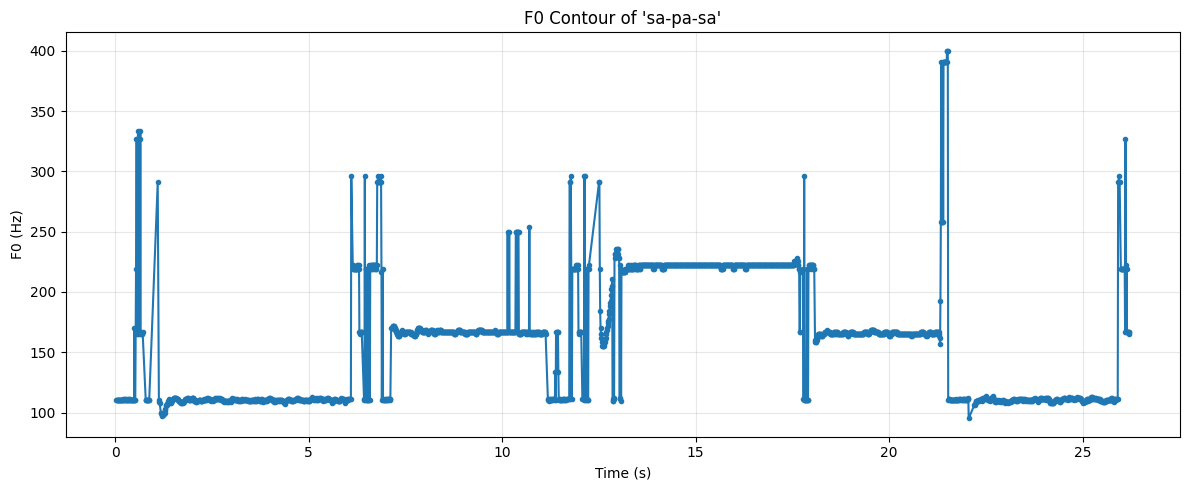

In [22]:
!gdown "https://drive.google.com/uc?id=11UkMo8c4qK1gxxtMN2QycooHVyXizK7U" -O sa-pa-sa.wav
import numpy as np
import scipy.io.wavfile
import matplotlib.pyplot as plt

# Load sa-pa-sa recording
rate_sapa, sig_sapa = scipy.io.wavfile.read("sa-pa-sa.wav")
sig_sapa = sig_sapa.astype(np.float32)

print("Sampling rate:", rate_sapa)
print("Samples:", len(sig_sapa))
print("Duration:", len(sig_sapa) / rate_sapa, "seconds")

# Mean subtraction
sig_sapa = sig_sapa - np.mean(sig_sapa)

# Same settings used for speech analysis
sapa_frameSize = 0.025
sapa_frameShift = 0.010

Frames_sapa = FrameSig(
    sig_sapa,
    sapa_frameSize,
    sapa_frameShift,
    windowing
)

# Estimate F0
EstimatedF0_sapa = []

for frame in Frames_sapa:
    voiced, f0 = VoicedVSUnvoiced(
        frame,
        PeakThreshold,
        rate=rate_sapa
    )

    EstimatedF0_sapa.append(f0 if voiced else 0.0)

EstimatedF0_sapa = np.array(EstimatedF0_sapa)

# Time at centre of each frame
frame_length_sapa = int(round(sapa_frameSize * rate_sapa))
frame_step_sapa = int(round(sapa_frameShift * rate_sapa))

frame_times_sapa = (
    np.arange(len(Frames_sapa)) * frame_step_sapa
    + frame_length_sapa / 2
) / rate_sapa

# Plot F0 contour
voiced_mask_sapa = EstimatedF0_sapa > 0

plt.figure(figsize=(12, 5))

plt.plot(
    frame_times_sapa[voiced_mask_sapa],
    EstimatedF0_sapa[voiced_mask_sapa],
    'o-',
    markersize=3
)

plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.title("F0 Contour of 'sa-pa-sa'")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 F0 Contour of 'sa-pa-sa'

- The $F_0$ contour shows several fairly stable pitch regions, mainly around **110 Hz, 165 Hz and 220 Hz**.

- There are also some sudden spikes reaching **300–400 Hz**. These occur only for a few frames and are likely to be pitch-tracking errors rather than actual changes in the speaker's pitch.

- Some regions around **220 Hz** may also be octave-up errors, since 220 Hz is approximately twice 110 Hz. This can happen when the autocorrelation tracker selects a lag close to half of the actual pitch period.

- The unvoiced sounds such as **/s/ and /p/** should ideally have no $F_0$. However, the plot shows some $F_0$ estimates in regions where the signal may be unvoiced, showing that the system sometimes incorrectly detects them as voiced.

- Overall, the contour captures the main periodic parts of the recording, but it also shows some **false detections and octave errors** due to the limitations of the autocorrelation-based pitch tracker.

### 9.4 Autocorrelation Roll-off

The autocorrelation decreases with increasing lag because, for a finite speech frame, there are fewer overlapping samples as the lag becomes larger. Hence, the correlation value naturally becomes smaller.

This can be reduced by using **normalized autocorrelation**, where the correlation is adjusted according to the number of overlapping samples. Another approach is to use **unbiased autocorrelation**, which also compensates for the decreasing number of samples at larger lags.

#### 10) Provide a detailed report of your observations for each experiment, including your findings from Section 2 (manual annotation) and Section 6 (evaluation against your manual ground truth).


### Section 2 – Manual Annotation

- The speech signal was manually divided into voiced, unvoiced, and silent regions.
- Voiced regions were mainly associated with vowels, while unvoiced regions occurred mainly around consonants. Silence was mainly present during pauses between speech segments.
- The manual annotation provided the ground truth for evaluating the automatic classification in Section 6.

### Section 6 – Evaluation against Manual Ground Truth

- The automatic voicing and silence detection was compared with the manual annotation.
- The system was able to identify the main voiced regions correctly, but some errors occurred near transitions between voiced, unvoiced and silent regions.
- Short or weak speech segments were more difficult to classify correctly.
- The results show that the choice of thresholds has an important effect on the voicing and silence decisions.

### Section 7 – Illustration

- The waveform was successfully labelled as **voiced, unvoiced and silent**, and the \(F_0\) contour was plotted for the voiced regions.
- The voiced regions showed clear periodic waveform patterns and measurable \(F_0\) values.
- Some sudden changes in $F_0$ were observed due to pitch-tracking errors.

### Section 8 – Keele Database Evaluation

- The system was evaluated on all **10 Keele speakers** using the laryngograph-based reference.
- The pooled results were **31.36% miss rate, 25.22% false-alarm rate, 3.87% GPE and 2.68% FPE**.
- Female speakers were easier to track than male speakers, mainly because the higher female \(F_0\) gives more pitch periods within the analysis window.
- The gross-error analysis showed that errors were mainly concentrated near a ratio of **2**, indicating octave-up errors.